# Sales Time Series Data Analysis
In this notebook, all the sales data is analyzed to check if there are any relevant annual time series patterns (seasonality, trend, stationarity and noise).

It uses a line plot and a box plot to check seasonality and trend patterns on the data, as well seasonal decomposition, that also allows to see the data's noise. The ADF test is used to check data's stationarity.

This is analysis is made for the whole dataset and for each granularity.

# 1. Load data

## 1. 1. Load data and check general info

In [2]:
import pandas as pd
import numpy as np

df_sales = pd.read_csv('../data/train.csv', index_col='id')

df_sales['date'] = pd.to_datetime(df_sales['date'])

# Remove august, 2017 since it's not a full month
# and may get the analysis biased
df_sales = df_sales[df_sales['date'] < '2017-08-01']

display(df_sales)

,date,store_nbr,family,sales,onpromotion
id,,,,,
0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,2013-01-01,1,BABY CARE,0.000,0
2,2013-01-01,1,BEAUTY,0.000,0
3,2013-01-01,1,BEVERAGES,0.000,0
4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...
2974153,2017-07-31,9,POULTRY,470.513,1
2974154,2017-07-31,9,PREPARED FOODS,61.940,0
2974155,2017-07-31,9,PRODUCE,1517.552,6


In [2]:
# General data's info
print(df_sales.info())
display(df_sales.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 2974158 entries, 0 to 2974157
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    int64         
 2   family       object        
 3   sales        float64       
 4   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 136.1+ MB
None


,date,store_nbr,sales,onpromotion
count,2974158,2.974158e+06,2.974158e+06,2.974158e+06
mean,2015-04-16 19:59:16.860395776,2.750000e+01,3.568108e+02,2.572272e+00
min,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2014-02-23 00:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,2015-04-17 00:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2016-06-08 00:00:00,4.100000e+01,1.950000e+02,0.000000e+00
max,2017-07-31 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,NaN,1.558579e+01,1.100588e+03,1.217364e+01


In [3]:
# Amount of granularities
len(df_sales[['store_nbr', 'family']].drop_duplicates())

1782

# 2. Analysis for the whole data

## 2. 1. Trend Analysis

In [4]:
# Creating the daily and monthly datasets
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.rcParams['figure.figsize'] = (16, 8)

df_sales['month_year'] = df_sales['date'].dt.to_period('M').dt.start_time

df_sales_monthly = (
     df_sales.groupby('month_year')['sales'].sum()
    .reset_index()
    .sort_values(by='month_year')
)

display(df_sales_monthly.head())
display(df_sales_monthly.tail())

,month_year,sales
0,2013-01-01,1.032762e+07
1,2013-02-01,9.658960e+06
2,2013-03-01,1.142850e+07
3,2013-04-01,1.099346e+07
4,2013-05-01,1.159770e+07


,month_year,sales
50,2017-03-01,2.670402e+07
51,2017-04-01,2.589531e+07
52,2017-05-01,2.691185e+07
53,2017-06-01,2.568282e+07
54,2017-07-01,2.701148e+07


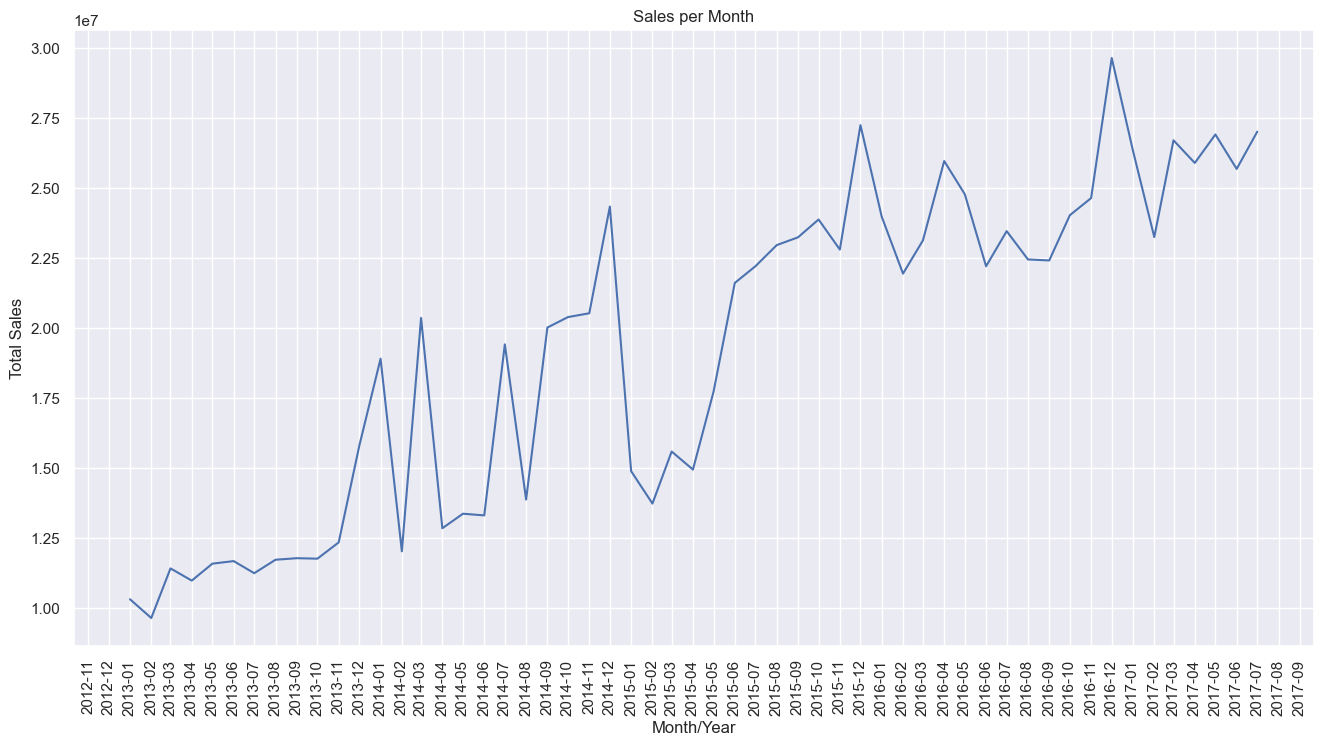

In [5]:
import matplotlib.dates as mdates

# Creating lineplot to check trend visually
ax = sns.lineplot(
    data=df_sales_monthly,
    x='month_year',
    y='sales'
)

ax.set_xlabel('Month/Year')
ax.set_ylabel('Total Sales')
ax.set_title('Sales per Month')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)

plt.show()

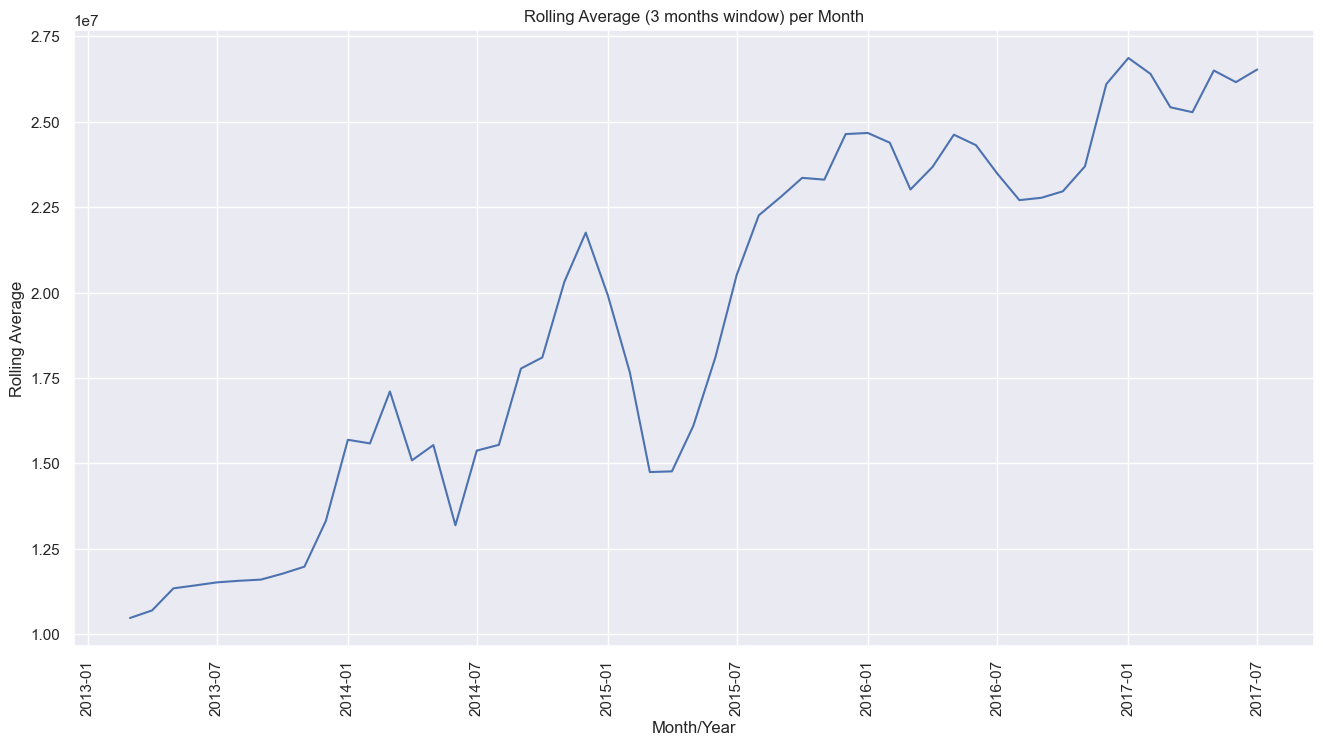

In [6]:
# Calculating rolling mean to check trend numerically
df_sales_monthly["rolling_avg"] = df_sales_monthly["sales"].rolling(window=3).mean()

ax = sns.lineplot(
    data=df_sales_monthly,
    x='month_year',
    y='rolling_avg'
)

ax.set_xlabel('Month/Year')
ax.set_ylabel('Rolling Average')

ax.set_title('Rolling Average (3 months window) per Month')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)

plt.show()

In both plots it's possible a growing trend.

## 2. 2. Seasonality

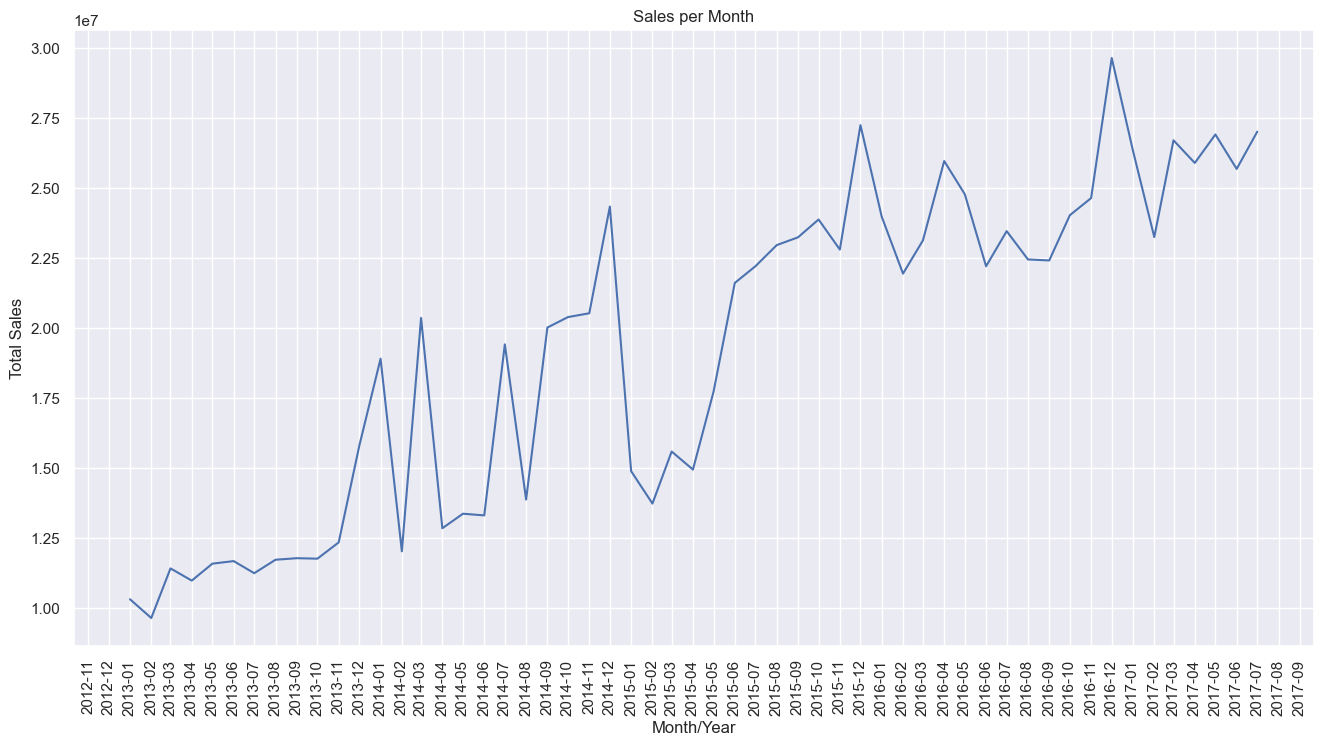

In [7]:
ax = sns.lineplot(
    data=df_sales_monthly,
    x='month_year',
    y='sales'
)

ax.set_xlabel('Month/Year')
ax.set_ylabel('Total Sales')
ax.set_title('Sales per Month')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=90)

plt.show()

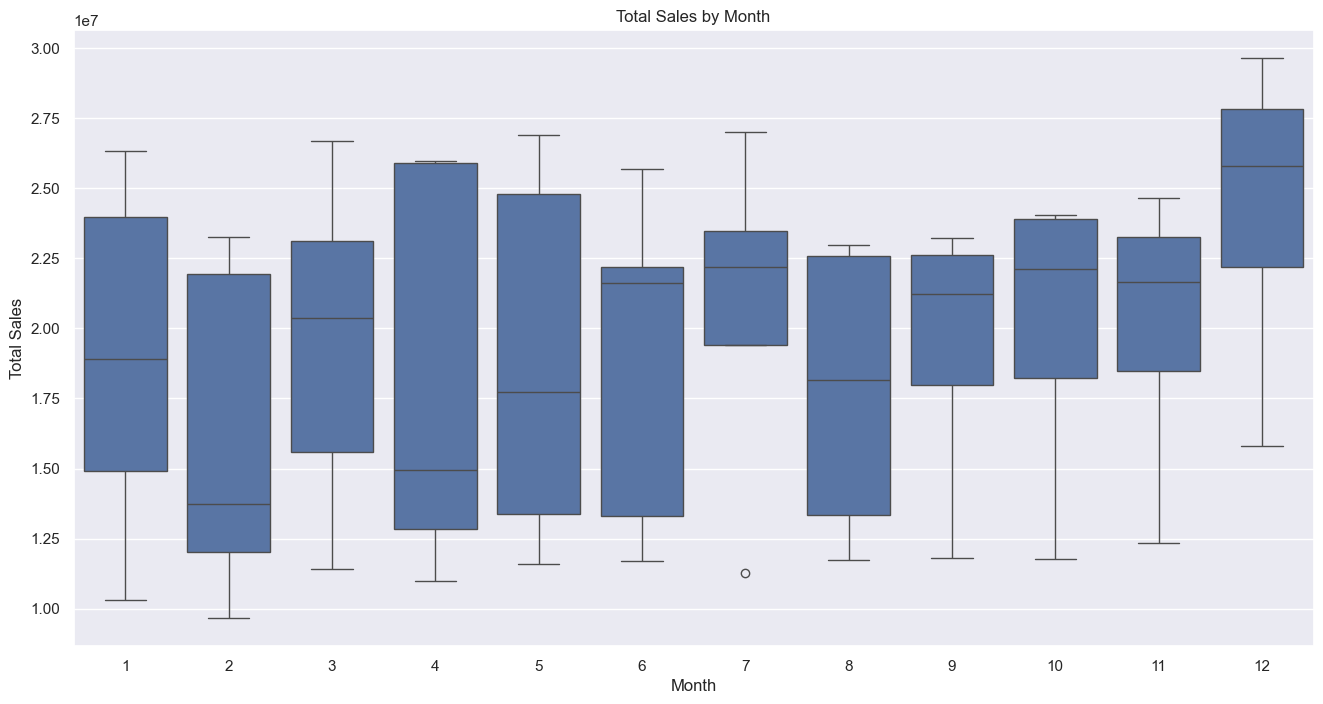

,month,sales
6,7,1.033631e+08
2,3,9.722849e+07
11,12,9.702784e+07
5,6,9.451670e+07
0,1,9.444215e+07
4,5,9.439914e+07
3,4,9.066812e+07
1,2,8.063723e+07
10,11,8.033579e+07
9,10,8.008038e+07


In [8]:
# Boxplot by month
df_sales_monthly['month'] = df_sales_monthly['month_year'].dt.month

ax = sns.boxplot(
    data=df_sales_monthly,
    x='month',
    y='sales'
)

ax.set_title('Total Sales by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')

plt.show()

display(df_sales_monthly.groupby('month')['sales'].sum().reset_index().sort_values(by='sales', ascending=False))

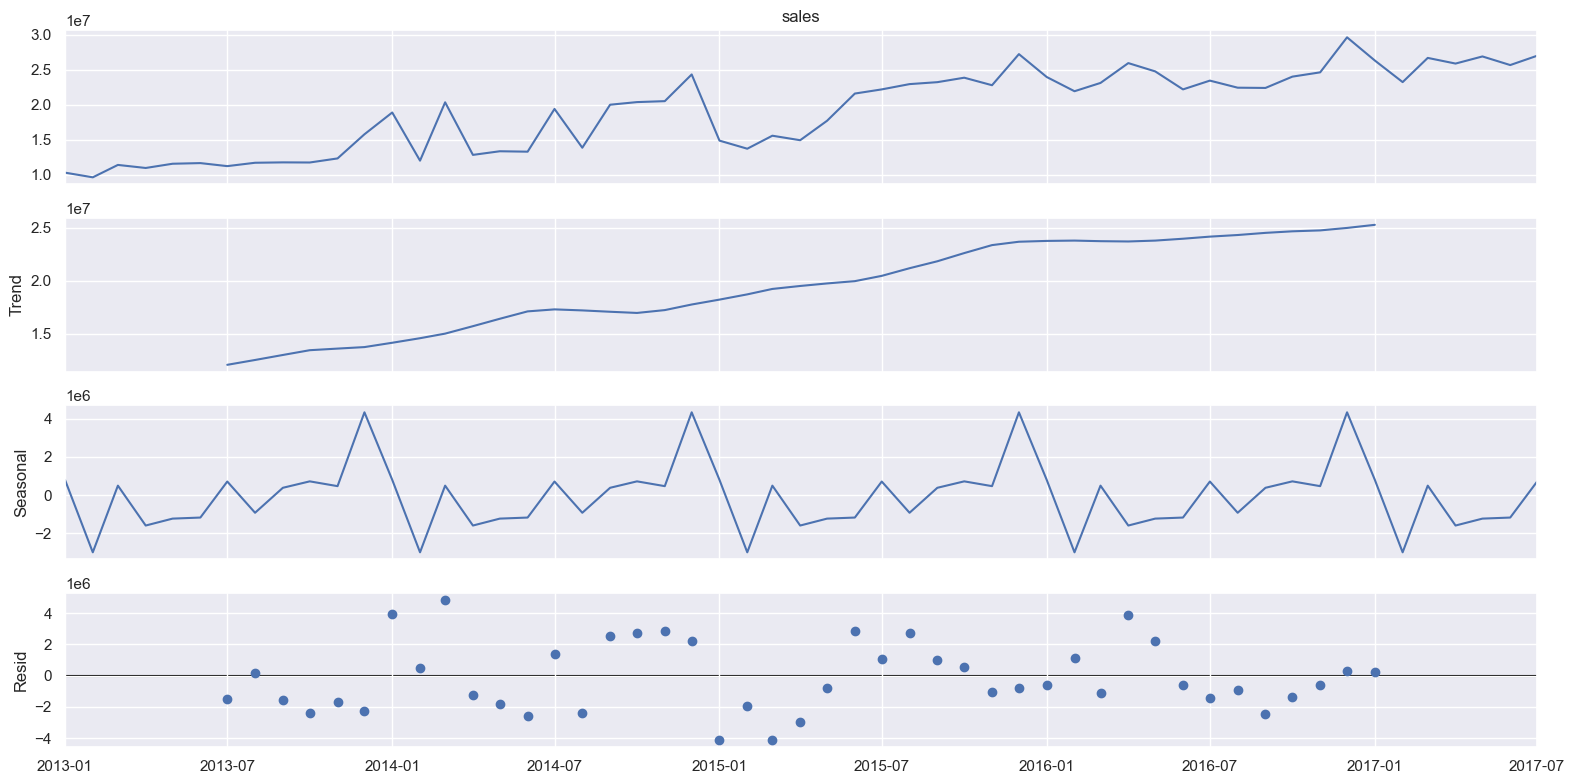

In [9]:
# Using seasonal decompose
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(
    df_sales_monthly.set_index("month_year")["sales"],
    model="additive",
    period=12
)

result.plot()
plt.show()

In [10]:
# Variance by component
import numpy as np

trend_var = np.var(result.trend.dropna())
season_var = np.var(result.seasonal.dropna())
resid_var = np.var(result.resid.dropna())
total_var = trend_var + season_var + resid_var

print(f"Trend: {trend_var / total_var:.2%}")
print(f"Seasonality: {season_var / total_var:.2%}")
print(f"Noise: {resid_var / total_var:.2%}")

Trend: 69.00%
Seasonality: 11.79%
Noise: 19.22%


It's possible to see the following seasonality patterns:
- a peak in december followed by a decrease in the sales in january;
- some peaks in the middle of the year.

However, by the variance by component analysis we can see that the seasonality one is not relevant. This may be seen because this analysis is being done for the whole data.

The decomposition confirms the growing trend seen in the past analysis.

# 3. Analysis for each granularity

## 3. 1. Calculate components by granularity

In [11]:
from tqdm import tqdm
from statsmodels.tsa.stattools import adfuller

results = []

df_sales_monthly_by_granularity = df_sales.groupby(['store_nbr', 'family', 'month_year'])['sales'].sum().reset_index()

for keys, group in tqdm(df_sales_monthly_by_granularity.groupby(['store_nbr', 'family']), desc='Calculating components info'):
    series = group['sales']

    try:
        decomposition = seasonal_decompose(series, model='additive', period=12)

        trend = decomposition.trend
        seasonal = decomposition.seasonal
        resid = decomposition.resid

        def component_strength(comp, resid):
            valid = comp.notna() & resid.notna()

            if valid.sum() == 0:
                return np.nan
            
            return max(0, 1 - np.var(resid[valid]) / np.var(comp[valid] + resid[valid]))

        seasonal_strength = component_strength(seasonal, resid)
        trend_strength = component_strength(trend, resid)
        noise_strength = 1 - max(seasonal_strength, trend_strength)

        non_zero_series = series[series > 0]

        # Stationarity
        if len(non_zero_series) > 0:
            adf_result = adfuller(series.dropna())
            p_value = adf_result[1]
            stationary = p_value < 0.05
        else:
            p_value = None
            stationary = True

        # Intermittency classification

        if len(non_zero_series) > 1:
            cv2 = (np.std(non_zero_series) / np.mean(non_zero_series)) ** 2
        else:
            cv2 = 0

        adi = len(series) / len(non_zero_series) if len(non_zero_series) > 0 else np.inf

        if adi <= 1.32 and cv2 <= 0.49:
            demand_type = 'smooth'
        elif adi > 1.32 and cv2 <= 0.49:
            demand_type = 'intermittent'
        elif adi <= 1.32 and cv2 > 0.49:
            demand_type = 'erratic'
        else:
            demand_type = 'lumpy'

        # Seasonality classification
        if seasonal_strength < 0.3:
            seasonality_classification = 'weak'
        elif seasonal_strength <= 0.6:
            seasonality_classification = 'moderate'
        else:
            seasonality_classification = 'strong'

        # Trend classification
        if trend_strength < 0.3:
            trend_classification = 'weak'
        elif trend_strength <= 0.6:
            trend_classification = 'moderate'
        else:
            trend_classification = 'strong'

        # Noise classification
        if noise_strength < 0.3:
            noise_classification = 'weak'
        elif noise_strength <= 0.6:
            noise_classification = 'moderate'
        else:
            noise_classification = 'strong'

        results.append({
            'group': keys,
            'seasonal_strength': seasonal_strength,
            'seasonality_classification': seasonality_classification,
            'trend_strength': trend_strength,
            'trend_classification': trend_classification,
            'noise_strength': noise_strength,
            'noise_classification': noise_classification,
            'stationary': stationary,
            'p_value': p_value,
            'demand_type': demand_type,
            'total_sales': series.sum()
        })


    except Exception as e:
        print(f"Error for group {keys}: {e}")

df_time_series_analysis_results = pd.DataFrame(data=results)

display(df_time_series_analysis_results)

Calculating components info:   0%|          | 0/1782 [00:00<?, ?it/s]C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_7736\237432940.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return max(0, 1 - np.var(resid[valid]) / np.var(comp[valid] + resid[valid]))
Calculating components info:  14%|█▍        | 251/1782 [00:01<00:06, 251.82it/s]C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_7736\237432940.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return max(0, 1 - np.var(resid[valid]) / np.var(comp[valid] + resid[valid]))
Calculating components info:  16%|█▌        | 278/1782 [00:01<00:05, 252.34it/s]C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_7736\237432940.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return max(0, 1 - np.var(resid[valid]) / np.var(comp[valid] + resid[valid]))
Calculating components info:  19%|█▊        | 330/1782 [00:01<00:05, 250.63it/s]C:\Users\JoaoSierra\AppData\Local\Temp\ipykernel_7736\237432940.

,group,seasonal_strength,seasonality_classification,trend_strength,trend_classification,noise_strength,noise_classification,stationary,p_value,demand_type,total_sales
0,"(1, AUTOMOTIVE)",0.247563,weak,0.779891,strong,0.220109,weak,False,0.423240,smooth,5.404000e+03
1,"(1, BABY CARE)",0.000000,weak,0.000000,weak,1.000000,strong,True,NaN,intermittent,0.000000e+00
2,"(1, BEAUTY)",0.206211,weak,0.477109,moderate,0.522891,moderate,False,0.990436,smooth,3.997000e+03
3,"(1, BEVERAGES)",0.238415,weak,0.609566,strong,0.390434,moderate,False,0.687893,smooth,2.644117e+06
4,"(1, BOOKS)",0.248238,weak,0.600387,strong,0.399613,moderate,True,0.021903,intermittent,2.110000e+02
...,...,...,...,...,...,...,...,...,...,...,...
1777,"(54, POULTRY)",0.649345,strong,0.549710,moderate,0.350655,moderate,False,0.816012,smooth,8.789783e+04
1778,"(54, PREPARED FOODS)",0.722268,strong,0.743036,strong,0.256964,weak,False,0.701765,smooth,1.017500e+05
1779,"(54, PRODUCE)",0.246896,weak,0.656869,strong,0.343131,moderate,False,0.531464,intermittent,5.858287e+05
1780,"(54, SCHOOL AND OFFICE SUPPLIES)",0.335131,moderate,0.107810,weak,0.664869,strong,False,0.958257,lumpy,1.023000e+03


In [13]:
# Amount of granularities in each combination
granularities_in_each_combination = (
     df_time_series_analysis_results
    .groupby(['seasonality_classification', 'trend_classification', 'noise_classification', 'stationary'])
    .agg({
        'total_sales': ('sum', 'count')
    })
    .reset_index()
)

display(granularities_in_each_combination.sort_values(by=('total_sales', 'sum'), ascending=False))

seasonality_classification trend_classification noise_classification  \
                                                                          
18                     strong               strong                 weak   
6                    moderate               strong                 weak   
24                       weak             moderate             moderate   
28                       weak               strong             moderate   
14                     strong             moderate                 weak   
30                       weak               strong                 weak   
1                    moderate             moderate             moderate   
0                    moderate             moderate             moderate   
4                    moderate               strong             moderate   
7                    moderate               strong                 weak   
22                     strong                 weak                 weak   
19                     strong               strong                 weak   
26                       weak             moderate               strong   
13                     strong             moderate             moderate   
33                       weak                 weak               strong   
23                     strong                 weak                 weak   
27                       weak             moderate               strong   
11                   moderate                 weak               strong   
16                     strong               strong             moderate   
5                    moderate               strong             moderate   
3                    moderate             moderate               strong   
10                   moderate                 weak               strong   
15                     strong             moderate                 weak   
12                     strong             moderate             moderate   
9                    moderate                 weak             moderate   
32                       weak                 weak               strong   
25                       weak             moderate             moderate   
31                       weak               strong                 weak   
21                     strong                 weak             moderate   
2                    moderate             moderate               strong   
29                       weak               strong             moderate   
17                     strong               strong             moderate   
20                     strong                 weak             moderate   
8                    moderate                 weak             moderate   

   stationary   total_sales        
                        sum count  
18      False  2.603618e+08   117  
6       False  1.797539e+08   368  
24      False  1.442888e+08   178  
28      False  1.141179e+08    89  
14      False  5.460341e+07    58  
30      False  4.661511e+07   159  
1        True  3.729150e+07    63  
0       False  3.349421e+07    79  
4       False  3.080433e+07    71  
7        True  2.568717e+07    33  
22      False  2.340490e+07    40  
19       True  1.896295e+07    11  
26      False  1.245161e+07    36  
13       True  1.176704e+07    15  
33       True  9.445996e+06   128  
23       True  6.825538e+06     8  
27       True  6.286517e+06    21  
11       True  6.154154e+06    44  
16      False  4.782400e+06     6  
5        True  4.556149e+06    16  
3        True  4.360583e+06    18  
10      False  4.142455e+06    17  
15       True  3.995644e+06    15  
12      False  3.727910e+06     7  
9        True  3.367842e+06    26  
32      False  2.798790e+06    65  
25       True  2.406405e+06    44  
31       True  1.309797e+06     8  
21       True  1.279543e+06     7  
2       False  8.079717e+05     7  
29       True  7.576983e+05    15  
17       True  4.368330e+05     2  
20      False  1.239500e+05     6  
8       False  4.077700e+04     5

In [14]:
# Amount of granularities in demand type
granularities_in_each_demand_type = (
     df_time_series_analysis_results
    .groupby('demand_type')
    .agg({
        'total_sales': ('sum', 'count')
    })
    .reset_index()
)

display(granularities_in_each_demand_type.sort_values(by=('total_sales', 'sum'), ascending=False))

demand_type   total_sales      
                          sum count
3        smooth  8.589606e+08   895
0       erratic  1.043062e+08    89
1  intermittent  9.691191e+07   686
2         lumpy  1.032898e+06   112

## 3. 2. Analysis

### 3. 2. 1. Seasonality

In [15]:
seasonal_series = df_time_series_analysis_results[df_time_series_analysis_results['seasonality_classification'] != 'weak']
non_seasonal_series = df_time_series_analysis_results[df_time_series_analysis_results['seasonality_classification'] == 'weak']

display(
     df_time_series_analysis_results
    .groupby('seasonality_classification')['total_sales'].sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

print(f"{len(seasonal_series) / len(df_time_series_analysis_results):.2%} series have a moderate/strong seasonal component")
print(f"{len(non_seasonal_series) / len(df_time_series_analysis_results):.2%} series do not have a moderate/strong seasonal component")

print(f"\n\nSeasonal series sales median: {seasonal_series['total_sales'].median():.2f}")
print(f"Non-seasonal series sales median: {non_seasonal_series['total_sales'].median():.2f}")

,seasonality_classification,total_sales
1,strong,3.902719e+08
2,weak,3.404786e+08
0,moderate,3.304611e+08


58.31% series have a moderate/strong seasonal component
41.69% series do not have a moderate/strong seasonal component


Seasonal series sales median: 99398.71
Non-seasonal series sales median: 10333.00


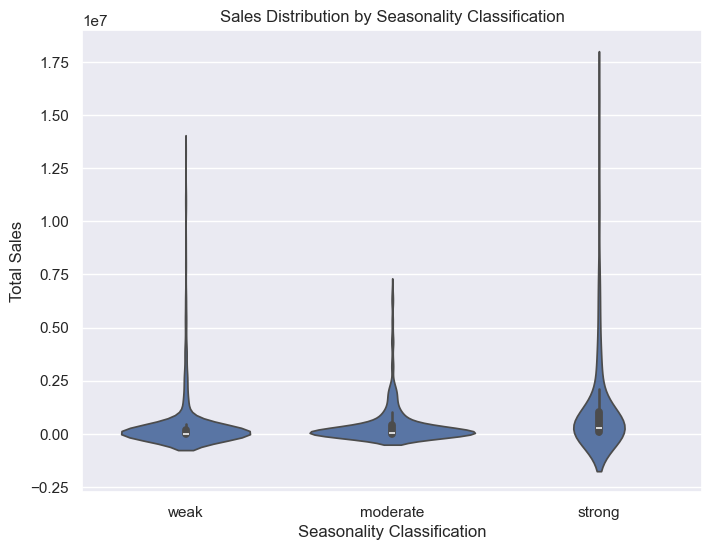

In [16]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='seasonality_classification',
    y='total_sales'
)

ax.set_title('Sales Distribution by Seasonality Classification')

ax.set_xlabel('Seasonality Classification')
ax.set_ylabel('Total Sales')

plt.show()

We can see that seasonal series have a greater median and a greater total sales amount.

### 3. 2. 2. Trend

In [17]:
trend_series = df_time_series_analysis_results[df_time_series_analysis_results['trend_classification'] != 'weak']
non_trend_series = df_time_series_analysis_results[df_time_series_analysis_results['trend_classification'] == 'weak']

display(
     df_time_series_analysis_results
    .groupby('trend_classification')['total_sales'].sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

print(f"{len(trend_series) / len(df_time_series_analysis_results):.2%} series have a moderate/strong trend component")
print(f"{len(non_trend_series) / len(df_time_series_analysis_results):.2%} series do not have a moderate/strong trend component")

print(f"\n\nSeries with trend's sales median: {trend_series['total_sales'].median():.2f}")
print(f"Series with no trend's sales median: {non_trend_series['total_sales'].median():.2f}")

,trend_classification,total_sales
1,strong,6.881461e+08
0,moderate,3.154816e+08
2,weak,5.758394e+07


80.58% series have a moderate/strong trend component
19.42% series do not have a moderate/strong trend component


Series with trend's sales median: 72617.99
Series with no trend's sales median: 2892.00


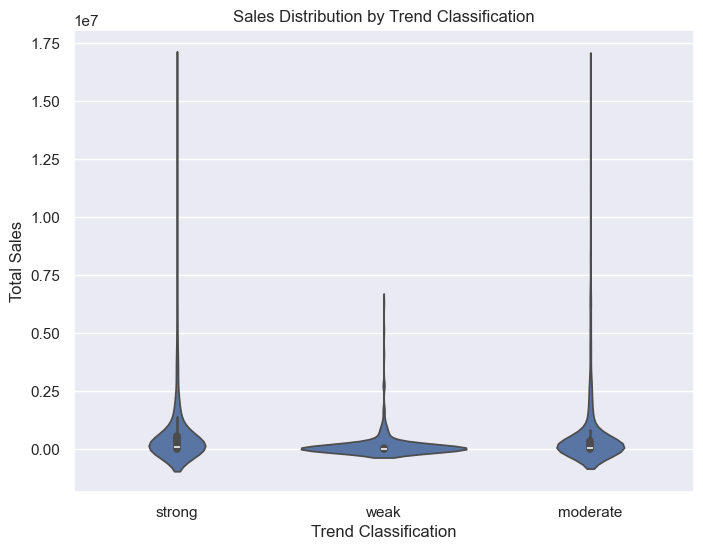

In [18]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='trend_classification',
    y='total_sales'
)

ax.set_title('Sales Distribution by Trend Classification')

ax.set_xlabel('Trend Classification')
ax.set_ylabel('Total Sales')

plt.show()

We can also see that the series with a trend have a greater median and a much greater total sales amount.

### 3. 2. 3. Noise

In [19]:
noisy_series = df_time_series_analysis_results[df_time_series_analysis_results['noise_classification'] == 'strong']
non_noisy_series = df_time_series_analysis_results[df_time_series_analysis_results['noise_classification'].isin(['moderate', 'weak'])]

display(
     df_time_series_analysis_results
    .groupby('noise_classification')['total_sales'].sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

print(f"{len(noisy_series)/len(df_time_series_analysis_results):.2%} series are noisy")
print(f"{len(non_noisy_series)/len(df_time_series_analysis_results):.2%} series are not noisy")

print(f"\n\nNoisy series' sales median: {noisy_series['total_sales'].median():.2f}")
print(f"Non-noisy series' sales median: {non_noisy_series['total_sales'].median():.2f}")

,noise_classification,total_sales
2,weak,6.215203e+08
0,moderate,3.932433e+08
1,strong,4.644807e+07


18.86% series are noisy
81.14% series are not noisy


Noisy series' sales median: 2305.00
Non-noisy series' sales median: 74285.00


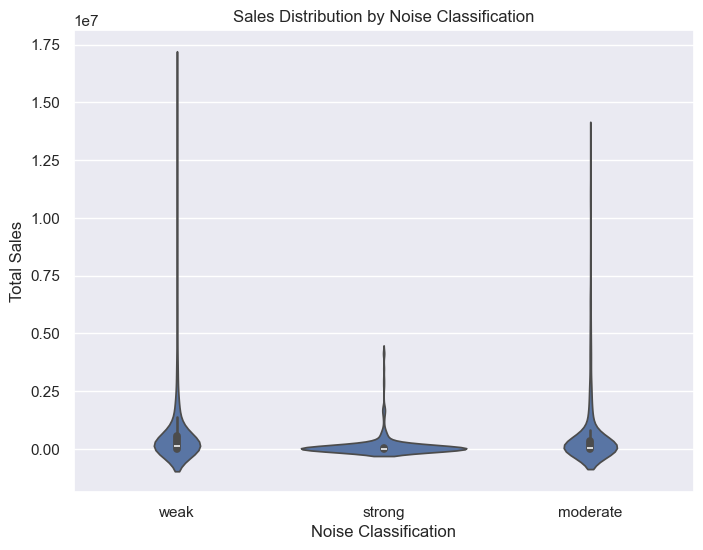

In [20]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='noise_classification',
    y='total_sales'
)

ax.set_title('Sales Distribution by Noise Classification')

ax.set_xlabel('Noise Classification')
ax.set_ylabel('Total Sales')

plt.show()

We can see that non-noisy series got a greater median and a much bigger total sales amount.

### 3. 2. 4. Stationarity

In [21]:
# Stationary series
stationary_series = df_time_series_analysis_results[df_time_series_analysis_results['stationary']]
non_stationary_series = df_time_series_analysis_results[df_time_series_analysis_results['stationary'] == False]

display(
     df_time_series_analysis_results
    .groupby('stationary')['total_sales'].sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

print(f"{len(stationary_series)/len(df_time_series_analysis_results):.2%} series are stationary")
print(f"{len(non_stationary_series)/len(df_time_series_analysis_results):.2%} series are not stationary")

print(f"\n\nStationary series' sales median: {stationary_series['total_sales'].median():.2f}")
print(f"Non-stationary series' sales median: {non_stationary_series['total_sales'].median():.2f}")

,stationary,total_sales
0,False,9.163203e+08
1,True,1.448914e+08


26.60% series are stationary
73.40% series are not stationary


Stationary series' sales median: 7330.50
Non-stationary series' sales median: 56666.63


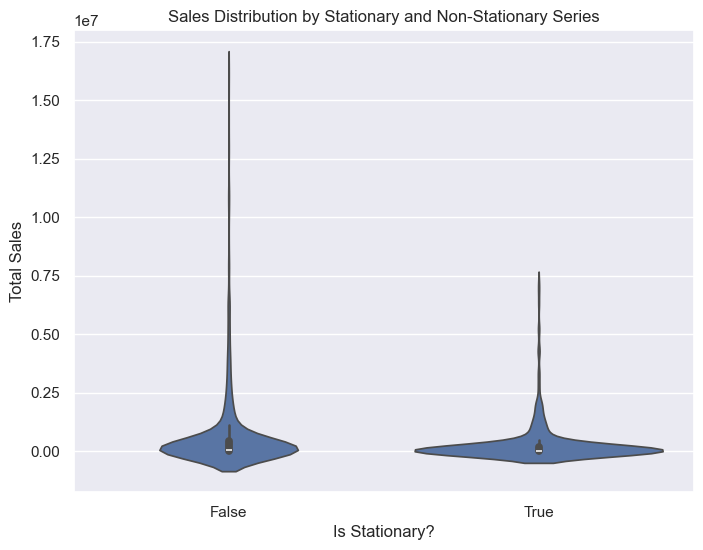

In [22]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='stationary',
    y='total_sales'
)

ax.set_title('Sales Distribution by Stationary and Non-Stationary Series')

ax.set_xlabel('Is Stationary?')
ax.set_ylabel('Total Sales')

plt.show()

Non-stationary series' sales median is greater with a much greater total sales amount.

### 3. 2. 5. Demand type

In [23]:
display(
     df_time_series_analysis_results
    .groupby('demand_type')['total_sales'].sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

,demand_type,total_sales
3,smooth,8.589606e+08
0,erratic,1.043062e+08
1,intermittent,9.691191e+07
2,lumpy,1.032898e+06


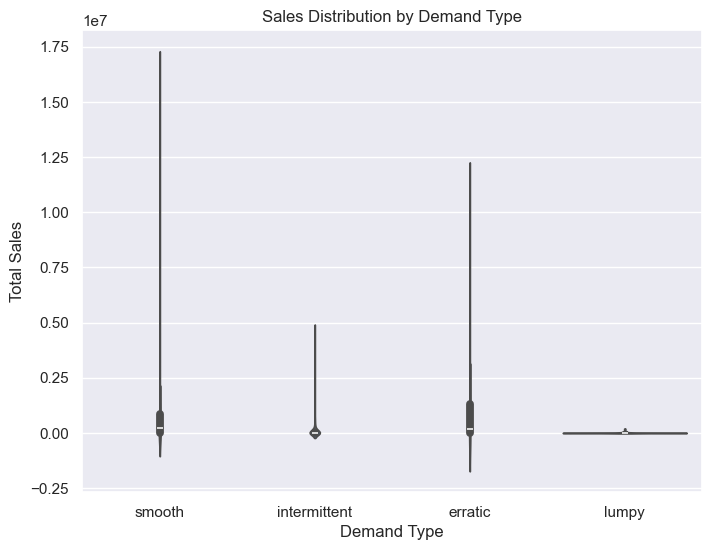

In [24]:
plt.rcParams['figure.figsize'] = (8, 6)

ax = sns.violinplot(
    data=df_time_series_analysis_results,
    x='demand_type',
    y='total_sales'
)

ax.set_title('Sales Distribution by Demand Type')

ax.set_xlabel('Demand Type')
ax.set_ylabel('Total Sales')

plt.show()

Smooth and erratic series' median are greater, and we can see a difference in the sales between the groups.

# 5. Summary

The analysis reveals that the majority of individual time series (store/family level) do exhibit a significant annual seasonality and a clear trend, including the series that are the most important to the business. These seasonal and trending series account for a significantly higher sales volume, identifying them as the primary revenue drivers.

Similarly, most series are not stationary. The demand type classification also proved valuable, showing that series with a 'Smooth' and 'Erratic' demand profile constitute the vast majority of sales volume, whereas 'Intermittent' and 'Lumpy' series represent a long tail of low-volume products.


<b>Conclusion for Modeling:</b> The fact of high important series being seasonal and with a trend must be taken into account for feature engineering. Time-based features such as month, day of the week, and week of the year are important for the model to accurately capture the behavior of the most impactful product series. We can say, as well, that probably different models will have to be used for the different series seen in the analysis.